<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session15: K-Nearest Neighbors (KNN) From Scratch</font></h3>
<h3 align="center">Zahra Amini</h3>

# Step0: Import Libraries

In [1]:
import numpy as np
from scipy.stats import mode
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import statistics

In [3]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

# Step1: Read Data

In [4]:
iris= load_iris()

In [5]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

# Step2: X, y

In [7]:
X = iris.data

y = iris.target

In [8]:
X.shape

(150, 4)

# Step3: Split Trainset and Testset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Step4: Data Visualization

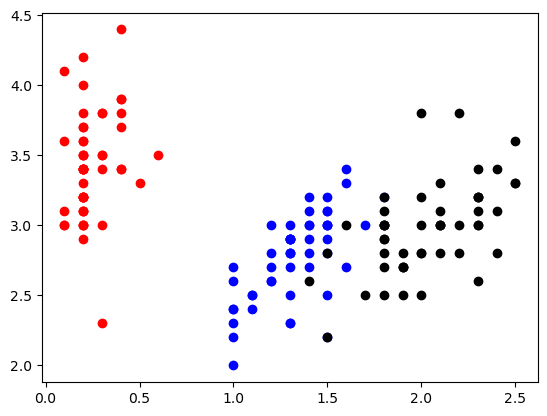

In [10]:
L0 = X[:50]
L1=X[50:100]
L2=X[100:150]

plt.scatter(L0[:,3], L0[:,1], color='red')

plt.scatter(L1[:,3], L1[:,1], color='blue')

plt.scatter(L2[:,3], L2[:,1], color='black')

# Step5: Distance Function

In [11]:
def eucledian(p1, p2):
    dis = np.sqrt(np.sum((p1-p2)**2))
    return dis

In [12]:
def corr(A, B):
    A = pd.Series(A)
    B= pd.Series(B)
    
    dis = 1- A.corr(B)
    return dis

In [13]:
A = X_test[1, :]
B = X_train[1, :]

corr(A, B)

0.3187597482162604

In [14]:
eucledian(A, B)

3.1733263305244863

In [15]:
def corr2(A, B):
    e1 = ((A-np.mean(A)).T/statistics.stdev(A))
    
    e2 = ((B-np.mean(B))/statistics.stdev(B))
    
    r = 1/(A.shape[0]-1) * np.sum(e1 *e2)
    
    dis = 1- r
    return dis

In [16]:
corr2(A, B)

0.3187597482162604

# Step6: KNN

In [17]:
def KNN_pred(x_train, y, x_test, k):
    pred_l = []
    for item in x_test:
        point_dis = []
        for j in range(len(x_train)):
            distance = eucledian(np.array(x_train[j, :]), item)
            
            point_dis.append(distance)
        point_dis = np.array(point_dis)
        
        dist = np.argsort(point_dis)[:k]
        
        labeles = y[dist]
        
        vote = mode(labeles)
        
        vote = vote.mode[0]
        
        pred_l.append(vote)
    return pred_l

In [18]:
y_pred = KNN_pred(X_train, y_train, X_test, 7)

C:\Users\amini\AppData\Local\Temp\ipykernel_2484\3268044505.py:15: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  vote = mode(labeles)


In [19]:
accuracy_score(y_test, y_pred)

1.0

In [20]:
mode([1,2,3,4,4,4,4,5,5,6])[0]

C:\Users\amini\AppData\Local\Temp\ipykernel_2484\3665470136.py:1: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode([1,2,3,4,4,4,4,5,5,6])[0]


array([4])

In [21]:
np.argsort(np.array([99,1,2,3,100,4,5,5,6]))

array([1, 2, 3, 5, 6, 7, 8, 0, 4], dtype=int64)

# Step6: Elbow Method for Choosing Reasonable K Values

In [22]:
error = []

for k in range(1, 40):
    pred_k = KNN_pred(X_train, y_train, X_test, k)
    error.append(np.mean(pred_k != y_test))

C:\Users\amini\AppData\Local\Temp\ipykernel_2484\3268044505.py:15: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  vote = mode(labeles)


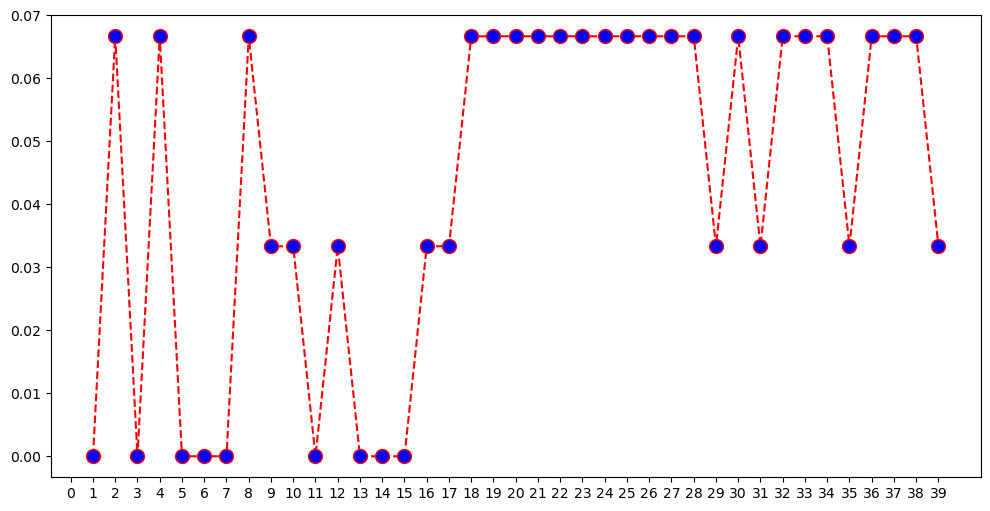

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(range(1, 40), error, color='red', linestyle='dashed',
        marker='o', markerfacecolor='blue', markersize=10)

plt.xticks(np.arange(0, 40, 1))
plt.show()